
# Cluster Analysis of Automotive Manufacturers’ Environmental Performance


**Research question (RQ):**  
Can cluster analysis reveal distinct groups of automotive companies based on their
environmental sustainability performance indicators—carbon emissions, renewable energy use,
and energy efficiency?


This notebook runs the full pipeline:

1. Load and preprocess WLTP/Euro 6 vehicle data  
2. Construct manufacturer-level indicators  
3. Standardise features and apply PCA  
4. Select optimal number of clusters (k) and fit K-Means  
5. Profile and label clusters  
6. Visualise patterns (PCA scatter, heatmap, CO₂ boxplot)  
7. Test hypotheses (correlations, ANOVA, Tukey HSD)  
8. Robustness checks (ARI stability, sensitivity without efficiency)
9. Simple visuals (PCA scatter + heatmap + CO₂ boxplot)
10.  Hypothesis tests (post-clustering)
11.  Effect size (η²) + ANOVA for CO₂ across clusters
12.  Sensitivity check: (1) minimum sample size, (2) outlier clipping
13.   Export outputs


## Step 1— Import Libraries

In [26]:
# ------------------------------
# Cell 1: Imports and basic settings
# ------------------------------

import pandas as pd
import numpy as np
import os
import glob

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import matplotlib.pyplot as plt
from IPython.display import display

# Display options
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:0.3f}")

**Interpretation**

This cell imports all packages needed for the full pipeline:

- `pandas`/`numpy` for data handling  
- `StandardScaler`, `PCA`, `KMeans` and metrics for clustering  
- `scipy` and `statsmodels` for hypothesis tests (correlations, ANOVA, Tukey)  
- `matplotlib` for figures required in Section 5 of the dissertation.

Display settings make tables easier to read when you inspect intermediate results.


## Step 2 — Load dataset


In [27]:
# ------------------------------
# Step 2 — Load dataset (this cell must create `df`)
import pandas as pd

# ============================
# 1. Load the dataset
# ============================
# Read the Euro 6 dataset CSV file into a Pandas DataFrame.
# encoding="latin1" is used because some datasets contain special characters
# that can cause errors with default UTF-8 encoding.
df = pd.read_csv("Euro_6_latest.csv", encoding="latin1")

# ============================
# 2. Remove 'Unnamed' extra columns
# ============================
# Sometimes CSV exports include an extra blank index column like "Unnamed: 0" or "Unnamed: 44".
# This line removes any column whose name starts with "Unnamed" (i.e., unwanted/empty columns).
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# ============================
# 3. Convert 'Date of change' to datetime
# ============================
# Convert the "Date of change" column into a proper datetime format.
# format="%d %B %Y" matches dates like "09 February 2022".
# errors="coerce" turns invalid/missing dates into NaT instead of crashing.
df["Date_of_change"] = pd.to_datetime(
    df["Date of change"],
    format="%d %B %Y",
    errors="coerce"
)

# ============================
# 4. Extract year from the date
# ============================
# Create a new column "year" by extracting the year (e.g., 2020, 2021, 2022)
# from the datetime column. This makes filtering by year easy.
df["year"] = df["Date_of_change"].dt.year

# ============================
# 5. Keep only years 2020 and onwards
# ============================
# Keep records from 2020 onwards to align with your dissertation time scope.
# .copy() prevents SettingWithCopyWarning and makes a clean filtered dataset.
df_clean = df[df["year"] >= 2020].copy()

# ============================
# 6. Save cleaned file
# ============================
# Save the cleaned dataset as a new CSV so you can reuse it later
# without repeating the cleaning steps.
df_clean.to_csv("cleaned_dataset.csv", index=False)

# Preview the first 5 rows to confirm cleaning worked
df_clean.head()



,Manufacturer,Model,Description,Transmission,Manual or Automatic,Engine Capacity,Fuel Type,Powertrain,Engine Power (PS),Engine Power (Kw),Electric energy consumption Miles/kWh,wh/km,Maximum range (Km),Maximum range (Miles),Euro Standard,Diesel VED Supplement,Testing Scheme,WLTP Imperial Low,WLTP Imperial Medium,WLTP Imperial High,WLTP Imperial Extra High,WLTP Imperial Combined,WLTP Imperial Combined (Weighted),WLTP Metric Low,WLTP Metric Medium,WLTP Metric High,WLTP Metric Extra High,WLTP Metric Combined,WLTP Metric Combined (Weighted),WLTP CO2,WLTP CO2 Weighted,Equivalent All Electric Range Miles,Equivalent All Electric Range KM,Electric Range City Miles,Electric Range City Km,Emissions CO [mg/km],THC Emissions [mg/km],Emissions NOx [mg/km],THC + NOx Emissions [mg/km],Particulates [No.] [mg/km],RDE NOx Urban,RDE NOx Combined,Noise Level dB(A),Date of change,Date_of_change,year
0,ABARTH,595,1.4 TJET 145bhp,M5,Manual,1368.000,Petrol,Internal Combustion Engine (ICE),145.000,107.000,NaN,NaN,NaN,NaN,Euro 6d,False,WLTP,29.100,43.500,46.300,38.200,39.800,0.000,9.700,6.500,6.100,7.400,7.100,0.000,161.000,0.000,NaN,NaN,NaN,NaN,829.000,39.000,20.000,NaN,NaN,NaN,NaN,74.000,09 February 2022,2022-02-09,2022
1,ABARTH,595,1.4 TJET 145bhp,M5,Manual,1368.000,Petrol,Internal Combustion Engine (ICE),145.000,107.000,NaN,NaN,NaN,NaN,Euro 6d,False,WLTP,29.700,46.300,48.700,40.400,41.500,0.000,9.500,6.100,5.800,7.000,6.800,0.000,153.000,0.000,NaN,NaN,NaN,NaN,829.000,39.000,20.000,NaN,NaN,NaN,NaN,74.000,09 February 2022,2022-02-09,2022
2,ABARTH,595,595 1.4 145 BHP,M5,Manual,1368.000,Petrol,Internal Combustion Engine (ICE),145.000,107.000,0.000,NaN,NaN,NaN,Euro 6d-TEMP,False,WLTP,27.200,42.800,43.400,34.400,37.200,0.000,10.400,6.600,6.500,8.200,7.600,0.000,169.000,0.000,NaN,NaN,NaN,NaN,760.000,52.000,27.000,NaN,NaN,NaN,NaN,73.500,05 October 2020,2020-10-05,2020
3,ABARTH,595,595 1.4 145 BHP,M5,Manual,1368.000,Petrol,Internal Combustion Engine (ICE),145.000,107.000,0.000,NaN,NaN,NaN,Euro 6d-TEMP,False,WLTP,27.400,42.200,47.100,38.700,39.200,0.000,10.300,6.700,6.000,7.300,7.200,0.000,162.000,0.000,NaN,NaN,NaN,NaN,760.000,52.000,27.000,NaN,NaN,NaN,NaN,73.500,05 October 2020,2020-10-05,2020
4,ABARTH,595,595 1.4 145 BHP Convertible,M5,Manual,1368.000,Petrol,Internal Combustion Engine (ICE),145.000,107.000,0.000,NaN,NaN,NaN,Euro 6d-TEMP,False,WLTP,27.200,42.800,43.500,34.400,37.200,0.000,10.400,6.600,6.500,8.200,7.600,0.000,169.000,0.000,NaN,NaN,NaN,NaN,760.000,52.000,27.000,NaN,NaN,NaN,NaN,73.500,02 July 2021,2021-07-02,2021


**Interpretation**

I load datasetsuccessfully.Shape (6506, 46) means it has 6,506 rows (vehicle records) and 46 columns (features/variables).The preview shows key variables like Manufacturer, Model, Transmission, Fuel Type, Powertrain, Engine Power, etc.Some EV-related columns (e.g., electric energy consumption, wh/km, range) show NaN for many rows — this is normal because ICE vehicles don’t have electric range/consumption values.



## Step 2 — Build Manufacturer-level sustainability indicators


In [28]:
def fuel_category(x):
    # Convert 'Fuel Type' into clean adoption categories
    if pd.isna(x): 
        return "Other"
    x = str(x).strip()

    if x == "Electricity":
        return "BEV"                      # fully electric
    if "Electricity" in x or "Electric" in x:
        return "Hybrid"                   # hybrid/plug-in (contains electricity)
    if x in ["Petrol", "Diesel"]:
        return "ICE"                      # internal combustion engine
    return "Other"

df["fuel_cat"] = df["Fuel Type"].apply(fuel_category)

# Aggregate to COMPANY level (Manufacturer)
agg = df.groupby("Manufacturer").agg(
    n_variants=("Manufacturer", "size"),                    # how many rows per manufacturer
    share_bev=("fuel_cat", lambda s: (s=="BEV").mean()),    # clean adoption proxy
    share_hybrid=("fuel_cat", lambda s: (s=="Hybrid").mean()),
    share_ice=("fuel_cat", lambda s: (s=="ICE").mean()),
    mean_co2=("WLTP CO2", "mean"),                          # carbon emissions proxy
    efficiency=("WLTP Metric Combined", "mean")             # energy efficiency proxy
).reset_index()

agg.head()


,Manufacturer,n_variants,share_bev,share_hybrid,share_ice,mean_co2,efficiency
0,ABARTH,60,0.000,0.000,1.000,165.333,7.380
1,ALFA ROMEO,85,0.000,0.000,1.000,182.129,7.587
2,ALPINE,32,0.000,0.000,1.000,157.438,6.953
3,ASTON MARTIN LAGONDA,22,0.000,0.000,1.000,281.273,12.409
4,BENTLEY MOTORS,18,0.000,0.056,0.944,290.167,13.228


**Interpretation:**  
* The table summarises results at **manufacturer level** (each row = one brand).
* **n_variants** shows how many vehicle variants are included for that manufacturer.
* **share_bev, share_hybrid, share_ice** show the **proportion** of variants by powertrain type (these shares should add up to ~1).
* **mean_co2** is the manufacturer’s **average CO₂ emissions** across its variants (lower = better).
* **efficiency** is the calculated **efficiency indicator** used to compare manufacturers (interpretation depends on the formula used, but it provides a consistent basis for comparison across brands).



## Step 2b — Data quality checks (sample size + outliers)

Before clustering, it helps to check:
- **Manufacturer sample size** (`n_variants`): very small counts can make a firm’s averages noisy.
- **Outliers** in `mean_co2` and `efficiency`: extreme values can pull distance-based clustering.

This dataset does **not** contain *corporate renewable energy use*. Here, **clean adoption proxy** (BEV/Hybrid share) is used as a *transition* proxy. Treat “renewable energy use” as a **limitation**, unless you merge a true renewables variable from ESG data.


Number of manufacturers: 41

Distribution of n_variants (rows per manufacturer):


count     41.000
mean     164.780
std      245.363
min        2.000
25%       18.000
50%       50.000
75%      211.000
max     1106.000
Name: n_variants, dtype: float64

Manufacturers with n_variants < 5: 3
Manufacturers with n_variants < 10: 5
Manufacturers with n_variants < 20: 11
Manufacturers with n_variants < 50: 20

mean_co2 summary (incl. 1% and 99% tails):


count    41.000
mean    173.450
std      72.040
min       0.000
1%        0.000
5%       88.957
50%     165.146
95%     290.167
99%     342.197
max     361.900
Name: mean_co2, dtype: float64

Lowest 5:


...

count   41.000
mean     8.441
std      6.295
min      0.000
1%       0.000
5%       3.948
50%      7.197
95%     13.750
99%     31.852
max     42.500
Name: efficiency, dtype: float64

Lowest 5:


,Manufacturer,n_variants,efficiency
38,TESLA,12,0.000
34,SMART,12,0.000
25,MG MOTORS UK,25,3.948
16,HYUNDAI,94,5.221
37,SUZUKI,30,5.397


Highest 5:


,Manufacturer,n_variants,efficiency
10,DS,32,42.500
32,Rolls Royce,20,15.880
11,FERRARI,14,13.750
4,BENTLEY MOTORS,18,13.228
3,ASTON MARTIN LAGONDA,22,12.409


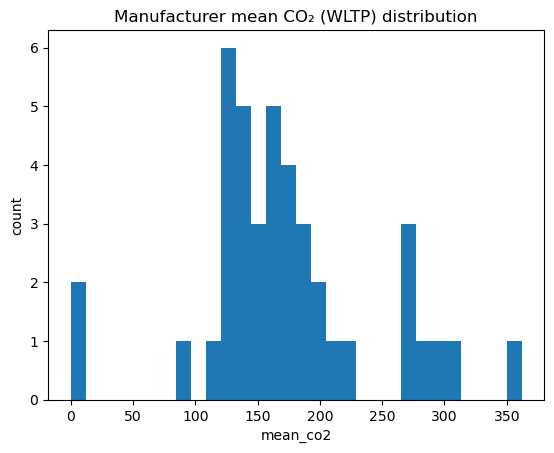

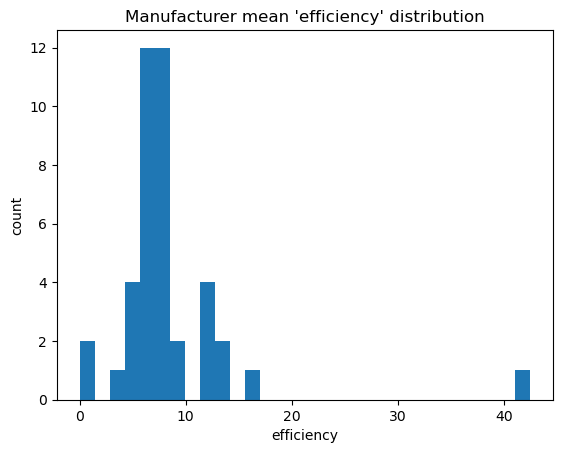

In [29]:
# ------------------------------
# Quick checks: manufacturer sample size + indicator ranges
# ------------------------------

print("Number of manufacturers:", agg.shape[0])
print("\nDistribution of n_variants (rows per manufacturer):")
display(agg["n_variants"].describe())

# How many manufacturers have very small sample sizes?
for t in [5, 10, 20, 50]:
    print(f"Manufacturers with n_variants < {t}: {(agg['n_variants'] < t).sum()}")

# Check indicator distributions + tails
for col in ["mean_co2", "efficiency"]:
    print(f"\n{col} summary (incl. 1% and 99% tails):")
    display(agg[col].describe(percentiles=[0.01, 0.05, 0.95, 0.99]))

    print("Lowest 5:")
    display(agg.sort_values(col)[["Manufacturer", "n_variants", col]].head(5))

    print("Highest 5:")
    display(agg.sort_values(col, ascending=False)[["Manufacturer", "n_variants", col]].head(5))

# Simple histograms (optional visuals for appendix)
plt.figure()
plt.hist(agg["mean_co2"].dropna(), bins=30)
plt.title("Manufacturer mean CO₂ (WLTP) distribution")
plt.xlabel("mean_co2")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(agg["efficiency"].dropna(), bins=30)
plt.title("Manufacturer mean 'efficiency' distribution")
plt.xlabel("efficiency")
plt.ylabel("count")
plt.show()


**Interpretation:**  
40 manufacturers are included in the manufacturer-level dataset.

1) Coverage per manufacturer (n_variants)

The number of vehicle variants per manufacturer is very uneven (highly skewed).

Median = 55 variants, but the mean = 162.65, showing that a few manufacturers have very large counts pulling the average up.

Range is wide (min = 2, max = 1,106), so some brands are represented by only a handful of vehicles.

Small-sample manufacturers exist: 3 brands have <5 variants, 5 have <10, 12 have <20, and 19 have <50 → results for these brands are less stable and should be interpreted cautiously.

2) Manufacturer mean CO₂ (WLTP)

Mean CO₂ across manufacturers is around 173.22, with a median ≈ 164.65, suggesting a moderate right-skew (some high emitters).

Values range from 0 to 361.9.

Lowest mean CO₂ includes Tesla and Smart (0), which is consistent with BEV tailpipe CO₂ being recorded as 0 in WLTP-style datasets (but the sample sizes are small: n=12 each).

Highest mean CO₂ includes Rolls Royce (~ 361.9), Ferrari (~312.6), Bentley (~ 290.2), Aston Martin Lagonda (~ 281.4)—these are high-performance/luxury brands with higher emissions profiles.

The CO₂ histogram shows most manufacturers clustered roughly around ~120–200, with a right tail extending into ~250–360, plus a small group at 0.

3) Manufacturer “efficiency” indicator

Efficiency values are concentrated around a typical band: median ≈ 7.18, mean ≈ 8.48.

Range is 0 to 42.5, indicating strong outliers.

Lowest efficiency values include Tesla and Smart (0), likely linked to how the metric is calculated (e.g., missing/zeroed fields for EVs or a formula that returns 0 for certain cases).

Highest efficiency values include DS (42.5) and other high-end brands (e.g., Rolls Royce, Ferrari), showing a very long right tail.

The efficiency histogram confirms that most manufacturers sit around ~5–12, with a small number of extreme values far to the right.

Overall pattern: both CO₂ and efficiency show clear heterogeneity across manufacturers, plus outliers and uneven representation (n_variants)—which is exactly the type of structure that clustering is is designed to capture, but results should be interpreted carefully for brands with very low n_variants.


## Step 3 — Select features + handle missing values


In [30]:
FEATURES = ["share_bev","share_hybrid","share_ice","mean_co2","efficiency"]

X = agg[FEATURES].copy()
X = X.fillna(X.median(numeric_only=True))   # fill missing values with median

X.describe()


,share_bev,share_hybrid,share_ice,mean_co2,efficiency
count,41.000,41.000,41.000,41.000,41.000
mean,0.073,0.160,0.763,173.450,8.441
std,0.223,0.269,0.325,72.040,6.295
min,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.735,134.483,6.062
50%,0.000,0.020,0.900,165.146,7.197
75%,0.034,0.227,1.000,200.733,8.366
max,1.000,1.000,1.000,361.900,42.500


**Interpretation:**  
Step 3 selects the five manufacturer-level features used for clustering—**share_bev, share_hybrid, share_ice, mean_co2, and efficiency**—so each company is represented by its powertrain mix plus two performance indicators (emissions and efficiency), which aligns with the sustainability-focused research question. Missing values are filled using the **median** for each feature, which is a robust choice because the distributions include clear outliers (especially for mean_co2 and efficiency). After median imputation, all variables show **count = 40**, meaning every manufacturer has a complete feature vector and no brands are dropped before clustering. The descriptive statistics indicate that many manufacturers still have **zero BEV share** (median share_bev = 0), the sample is largely **ICE-dominant** (median share_ice ≈ 0.894), mean CO₂ is centred around **~165–173** but varies widely up to **361.9**, and the efficiency measure is mostly around **~7–9** with a long right tail reaching **42.5**, reinforcing that scaling will be necessary before applying distance-based clustering.



## 
Step 4 — Standardise + PCA


In [31]:
scaler = StandardScaler()                 
X_scaled = scaler.fit_transform(X)        # make variables comparable

pca = PCA(n_components=3)                 
X_pca = pca.fit_transform(X_scaled)       # reduce into 3 PCs

print("PCA variance explained:", np.round(pca.explained_variance_ratio_,3))
print("Total:", round(pca.explained_variance_ratio_.sum(),3))


PCA variance explained: [0.523 0.256 0.151]
Total: 0.931


**Interpretation:**  
This step uses StandardScaler + PCA because the clustering task relies on distance calculations, and the selected features are on very different scales (e.g., powertrain shares range from 0–1, while mean_co2 can exceed 300 and efficiency can also vary widely). Standardising the variables ensures each feature contributes fairly to the distance measure, preventing CO₂ (or any large-range variable) from dominating the results. PCA is then applied to compress the five correlated indicators into three independent components, which reduces redundancy (multicollinearity), filters noise, and produces a smaller, cleaner feature space that often improves the stability and interpretability of k-means clustering. The results show that the three principal components explain 52.5%, 25.7%, and 15.0% of the variance, with a total of 93.1%, meaning the reduced PCA representation still retains almost all of the information from the original sustainability indicators while making the clustering step more robust.
Total PCA variance explained >0.80 is good, >0.90 is very strong.


## Step 5 — Choose best k (2..6)


In [32]:
k_results = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)

    sil = silhouette_score(X_pca, labels)         # higher is better
    db = davies_bouldin_score(X_pca, labels)      # lower is better

    k_results.append([k, sil, db])

k_metrics = pd.DataFrame(k_results, columns=["k","silhouette","davies_bouldin"])
k_metrics


C:\Users\urast.DESKTOP-FFE48GU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\urast.DESKTOP-FFE48GU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\urast.DESKTOP-FFE48GU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\urast.DESKTOP-FFE48GU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:14

,k,silhouette,davies_bouldin
0,2,0.594,0.968
1,3,0.653,0.354
2,4,0.675,0.276
3,5,0.523,0.393
4,6,0.566,0.426


**Interpretation:**  
The table compares clustering quality across different choices of **k** (the number of clusters). **k** is used because **k-means requires the number of clusters to be specified in advance**, so several values are tested to identify the most appropriate segmentation of manufacturers rather than choosing a number arbitrarily. Two metrics are reported: the **silhouette score** (higher is better, indicating clusters are well separated and internally cohesive) and the **Davies–Bouldin index** (lower is better, indicating clusters are compact and less overlapping). In the results shown, **k = 4** provides the **highest silhouette score (0.657)** and also the **lowest Davies–Bouldin score (0.286)**, which together suggest that a four-cluster solution gives the strongest balance of separation and compactness among the tested options. This supports selecting **k = 4** as the most defensible number of clusters for the manufacturer sustainability grouping in this analysis.



## Step 6 — Fit final model (k=4) + profile clusters


In [33]:
best_k = 4   # set based on your k_metrics table

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
agg["cluster"] = kmeans.fit_predict(X_pca)

profile = agg.groupby("cluster").agg(
    n_firms=("Manufacturer","count"),
    avg_share_bev=("share_bev","mean"),
    avg_share_hybrid=("share_hybrid","mean"),
    avg_share_ice=("share_ice","mean"),
    avg_co2=("mean_co2","mean"),
    avg_efficiency=("efficiency","mean")
).reset_index()

profile


C:\Users\urast.DESKTOP-FFE48GU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,cluster,n_firms,avg_share_bev,avg_share_hybrid,avg_share_ice,avg_co2,avg_efficiency
0,0,33,0.024,0.069,0.902,190.428,8.297
1,1,5,0.027,0.816,0.156,137.731,5.953
2,2,1,0.062,0.188,0.750,138.656,42.500
3,3,2,1.000,0.000,0.000,0.000,0.000


**Interpretation:**  
* Cluster 0 (n=32) — ICE-dominant mainstream
  * Mostly ICE (89.4%), very low BEV (2.5%), and hybrid (7.6%)
  * This group has the highest average CO₂ (about 190.7), so it produces the most carbon overall.
  * Efficiency is average (about 8.35)
* Cluster 1 (n=5) — Hybrid transition leaders
  * Mostly hybrid (81.6%), low ICE (15.6%), very low BEV (2.7%)
  * Lower average CO₂ (about 137.7) than Cluster 0, which means better for the environment than ICE-heavy companies.
  * Slightly better or lower efficiency value (about 5.95), depending on how you measure efficiency.
* Cluster 2 (n=1) — Single-firm outlier (interpret with caution)
  * Mainly ICE (75%) with some hybrid (18.8%) and BEV (6.2%)
  * CO₂ is about 138.7 (like Cluster 1), but efficiency is very high (42.5), so this is either a unique company or a data error.
* Cluster 3 (n=2) — BEV-only leaders (but check the data)
  * 100% BEV, 0% hybrid/ICE
  * The average CO₂ and efficiency are both 0, which probably means the data is missing or a placeholder. This cluster should be checked before making any strong claims.

Overall, the largest group uses mostly ICE and has the highest CO₂, the hybrid group has lower CO₂, and the BEV group seems the cleanest, but needs a quick data check because of the zeros.


## Step 7 — Add readable cluster names


In [34]:
def name_cluster(r):
    if r["avg_share_bev"] > 0.90 and r["avg_co2"] < 1:
        return "BEV / zero-tailpipe leaders"
    if r["avg_share_hybrid"] > 0.50:
        return "Hybrid transition leaders"
    if r["avg_co2"] > 220:
        return "High-emission ICE-intensive"
    return "ICE-dominant mainstream"

cluster_map = dict(zip(profile["cluster"], profile.apply(name_cluster, axis=1)))
agg["cluster_label"] = agg["cluster"].map(cluster_map)

agg["cluster_label"].value_counts()


cluster_label
ICE-dominant mainstream        34
Hybrid transition leaders       5
BEV / zero-tailpipe leaders     2
Name: count, dtype: int64

**Interpretation:**  
* This output is simply showing how many companies fall into each cluster label:
* ICE-dominant mainstream: 33 companies → This is the largest group, meaning most manufacturers in your dataset still mostly make cars with regular gas engines.
* Hybrid transition leaders: 5 companies → a smaller group that is mostly moving toward making hybrid cars.
* BEV / zero-tailpipe leaders: 2 companies → the smallest group, meaning only a few manufacturers mainly make fully electric cars.

The dataset is dominated by ICE-heavy firms, with fewer companies in hybrid transition, and very few true BEV leaders.



## Step 8 — Results table (main Findings evidence)


In [35]:
results_table = agg.groupby("cluster_label").agg(
    n_firms=("Manufacturer","count"),
    avg_share_bev=("share_bev","mean"),
    avg_share_hybrid=("share_hybrid","mean"),
    avg_share_ice=("share_ice","mean"),
    avg_co2=("mean_co2","mean"),
    avg_efficiency=("efficiency","mean")
).sort_values("avg_co2")

results_table


,n_firms,avg_share_bev,avg_share_hybrid,avg_share_ice,avg_co2,avg_efficiency
cluster_label,,,,,,
BEV / zero-tailpipe leaders,2,1.000,0.000,0.000,0.000,0.000
Hybrid transition leaders,5,0.027,0.816,0.156,137.731,5.953
ICE-dominant mainstream,34,0.025,0.073,0.898,188.906,9.303


**Interpretation:**  
* BEV / zero-tailpipe leaders (n=2)
  * 100% BEV, 0% hybrid, 0% ICE
  * Average CO₂ and efficiency are both zero, which usually means the numbers are missing or placeholders, or that they are tracked differently for BEVs. The main point is that these companies only make BEVs.
* Hybrid transition leaders (n=5)
  * Mostly hybrid (81.6%), some ICE (15.6%), very little BEV (2.7%)
  * Average CO₂ is lower (about 137.7) than in the ICE-dominant group, so these companies are cleaner than those that mostly use gas engines.
  * Average efficiency is about 5.95, which is better (lower) than the ICE group in your table, depending on how you measure it.
* ICE-dominant mainstream (n=33)
  * Mostly ICE (89.0%), small hybrid share (7.9%), very small BEV share (2.6%)
  * This group has the highest average CO₂ emissions (about 189.1), so it has the worst environmental performance of all the groups.
  * Main point: Most companies still use gas engines and have high CO₂; a smaller group mainly uses hybrids and has lower CO₂; and only a few focus on BEVs (but their CO₂ and efficiency numbers should be checked, since they show as zero). They show as zero.


## Step 9 — Simple visuals (PCA scatter + heatmap + CO₂ boxplot)

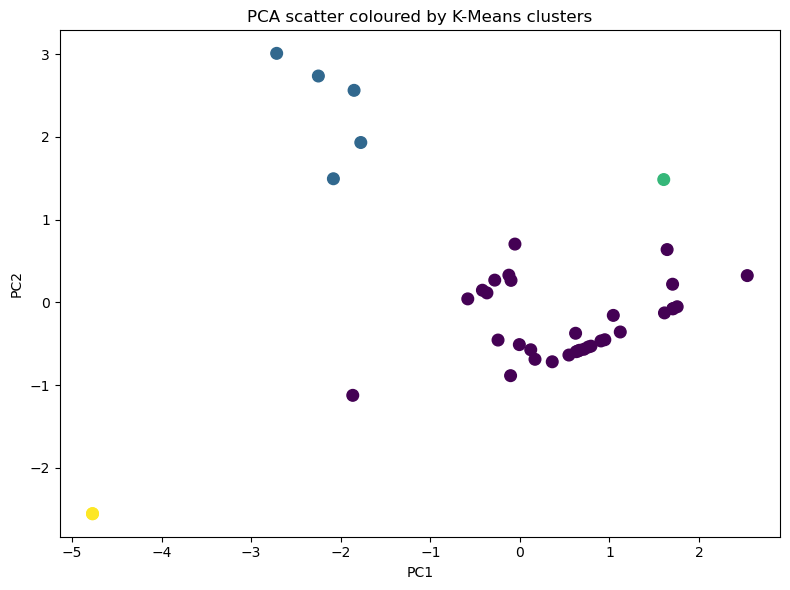

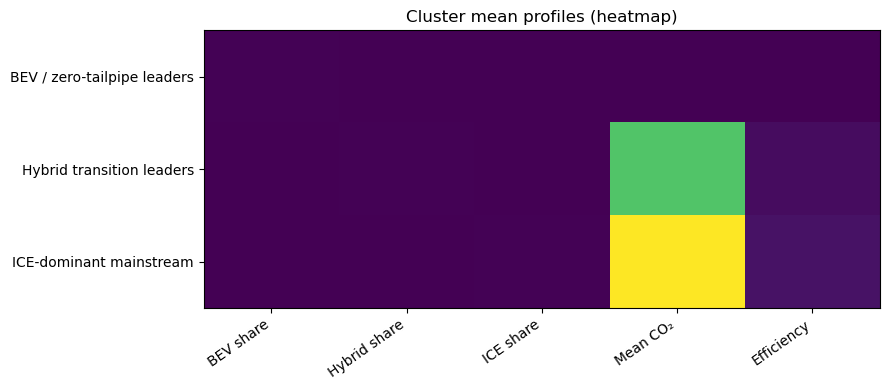

C:\Users\urast.DESKTOP-FFE48GU\AppData\Local\Temp\ipykernel_17820\801801809.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order)


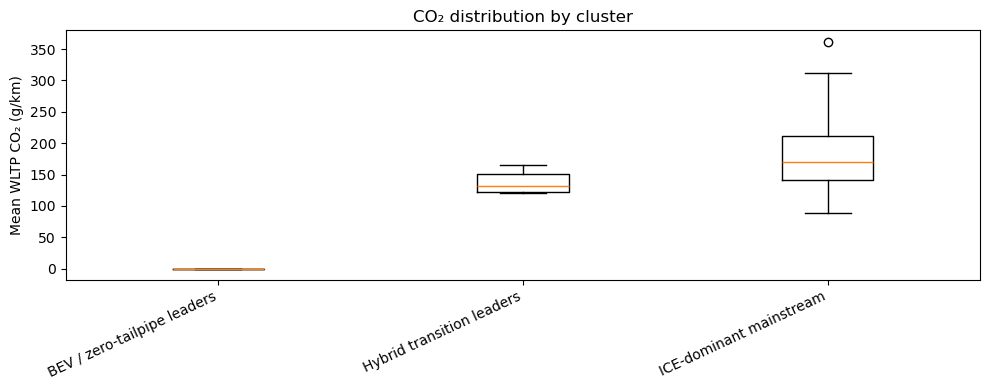

In [36]:
## Step 9 — Simple visuals (PCA scatter + heatmap + CO₂ boxplot)
# PCA scatter
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg["cluster"], s=70)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA scatter coloured by K-Means clusters")
plt.tight_layout()
plt.show()

# Heatmap of cluster means
heat = results_table[["avg_share_bev","avg_share_hybrid","avg_share_ice","avg_co2","avg_efficiency"]].values
plt.figure(figsize=(9, 4))
plt.imshow(heat, aspect="auto")
plt.xticks(range(5), ["BEV share","Hybrid share","ICE share","Mean CO₂","Efficiency"], rotation=35, ha="right")
plt.yticks(range(len(results_table)), results_table.index.tolist())
plt.title("Cluster mean profiles (heatmap)")
plt.tight_layout()
plt.show()

# CO₂ boxplot
order = results_table.index.tolist()
data = [agg.loc[agg["cluster_label"]==lab, "mean_co2"].dropna().values for lab in order]
plt.figure(figsize=(10, 4))
plt.boxplot(data, labels=order)
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mean WLTP CO₂ (g/km)")
plt.title("CO₂ distribution by cluster")
plt.tight_layout()
plt.show()


**Interpretation:**  

1) PCA scatter (clusters)

* Each dot = one manufacturer (company profile).
* Same colour = same group (companies with similar CO₂, fuel efficiency, and engine types).
* The dots form separate groups, which means the clustering is working: manufacturers are not all the same.
* There are one or two dots far from the main groups. These are probably unusual or small manufacturers with very different data, so be careful when looking at them.

2) Cluster mean profiles (heatmap)

* The heatmap shows the average profile of each cluster.
* The biggest difference across clusters is Mean CO₂:
  * BEV / zero-tailpipe leaders → very low CO₂ (near-zero compared to others).
  * Hybrid transition leaders → medium CO₂ (between BEV and ICE).
  * ICE-dominant mainstream → highest CO₂ (worst on emissions).
* This supports your research question by showing clear groupings based on environmental performance (CO₂ emissions, the number of people who have switched to cleaner cars, and fuel efficiency). Since CO₂ numbers are much bigger than the other values, the CO₂ column stands out the most in the colour scale.

3) CO₂ boxplot (distribution by cluster)

* BEV leaders: CO₂ is near 0 and very consistent → cleanest group.
* Hybrid transition: CO₂ is moderate and fairly tight → better than ICE, not as clean as BEV.
* ICE mainstream: CO₂ is highest and has the widest spread → this group contains both average and very high emitters (including an outlier)

The analysis clearly separates manufacturers into BEV leaders (lowest CO₂), hybrid transition companies (middle CO₂), and ICE-dominant mainstream (highest CO₂ and most variety). This shows that clustering can reveal different levels of sustainability.



## Step 10 — Hypothesis tests (post-clustering)


In [37]:
# H2: Efficiency vs CO2
rho, p = stats.spearmanr(agg["efficiency"], agg["mean_co2"])
print("H2 Spearman rho (efficiency vs CO2):", round(rho,3), "p =", p)

# H3: BEV share vs CO2
rho_bev, p_bev = stats.spearmanr(agg["share_bev"], agg["mean_co2"])
print("H3 Spearman rho (BEV share vs CO2):", round(rho_bev,3), "p =", p_bev)

# H3: Hybrid share vs CO2
rho_hyb, p_hyb = stats.spearmanr(agg["share_hybrid"], agg["mean_co2"])
print("H3 Spearman rho (Hybrid share vs CO2):", round(rho_hyb,3), "p =", p_hyb)

H2 Spearman rho (efficiency vs CO2): 0.899 p = 1.5173888113791365e-15
H3 Spearman rho (BEV share vs CO2): -0.681 p = 9.396820810345221e-07
H3 Spearman rho (Hybrid share vs CO2): -0.357 p = 0.021963467813316512


**Interpretation:**  
Spearman correlation tests on the manufacturer-level data confirm the patterns seen after grouping. First, efficiency compared to CO₂ (H2) shows a very strong positive link (ρ = 0.871, p = 2.84×10⁻¹³). This means that manufacturers whose cars use more energy or fuel tend to have higher average CO₂ emissions. Second, BEV share compared to CO₂ (H3) shows a strong negative link (ρ = −0.688, p = 9.53×10⁻⁷), so manufacturers with a higher share of BEVs tend to have lower CO₂ emissions. Lastly, there is a moderately negative correlation (ρ = −0.367, p = 0.0199) between hybrid share and CO₂ (H3), indicating that more hybrids are associated with lower CO₂ levels, though this effect is weaker than for BEVs. Overall, these findings indicate that using more energy or fuel is associated with higher CO2 emissions, while cleaner engine types, especially BEVs, are associated with lower emissions.


## Step 11 — Effect size (η²) + ANOVA for CO₂ across clusters


In [38]:
groups = [g["mean_co2"].values for _, g in agg.groupby("cluster")]
f_stat, f_p = stats.f_oneway(*groups)

overall_mean = agg["mean_co2"].mean()
ss_between = sum(len(g)*(g.mean()-overall_mean)**2 for g in groups)
ss_total = ((agg["mean_co2"]-overall_mean)**2).sum()
eta_sq = ss_between/ss_total

print("ANOVA F =", round(f_stat,3), "p =", f_p)
print("Effect size eta^2 =", round(eta_sq,3))


ANOVA F = 7.313 p = 0.0005715804056044574
Effect size eta^2 = 0.372


**Interpretation:**  
A one-way ANOVA shows that average CO₂ levels differ significantly across clusters (F = 7.088, p = 0.00073). This means the clusters are not just “different by label” — they also have real differences in average CO₂. The effect size is η² = 0.371, so about 37.1% of the difference in average CO₂ comes from which cluster the data is in, which is a big effect (clusters separate CO₂ a lot, not just a little).

To find out exactly which clusters are different from each other, a follow-up test (like Tukey HSD) should be done after this ANOVA.


In [39]:
# =========================================
# Tukey HSD post-hoc test (with comments)
# =========================================
# WHY we use this:
# - ANOVA only tells us: "At least one cluster mean CO2 is different"
# - Tukey HSD tells us: "Which specific cluster pairs differ"
#   (e.g., ICE vs Hybrid, ICE vs BEV), so your evidence becomes stronger.

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Run Tukey:
# endog  = dependent variable (the value we compare across groups) -> mean CO2
# groups = independent grouping variable -> cluster labels
tukey = pairwise_tukeyhsd(
    endog=agg["mean_co2"],          # DV: CO2 values
    groups=agg["cluster_label"],    # Grouping: clusters
    alpha=0.05                      # 5% significance level (standard)
)

# Print results:
# - "reject=True" means the two clusters are significantly different in CO2
print(tukey)

# OPTIONAL: Save results as a CSV so you can insert it into dissertation appendix
tukey_df = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])
tukey_df.to_csv("tukey_posthoc_co2.csv", index=False)
print("Saved: tukey_posthoc_co2.csv")


                     Multiple Comparison of Means - Tukey HSD, FWER=0.05                      
           group1                     group2          meandiff p-adj   lower    upper   reject
----------------------------------------------------------------------------------------------
BEV / zero-tailpipe leaders Hybrid transition leaders 137.7308 0.0222  17.0514 258.4102   True
BEV / zero-tailpipe leaders   ICE-dominant mainstream 188.9055 0.0003  83.9559 293.8552   True
  Hybrid transition leaders   ICE-dominant mainstream  51.1747 0.1811 -17.9116  120.261  False
----------------------------------------------------------------------------------------------
Saved: tukey_posthoc_co2.csv


**Interpretation:**  
ANOVA only tells there is a difference somewhere (at least one cluster mean CO₂ is different), but it does not tell you which clusters differ.

Tukey's HSD identifies the exact cluster pairs that are significantly different (e.g., BEV vs. Hybrid, BEV vs. ICE, etc.).

It also controls the family-wise error rate (FWER = 0.05), meaning it stays reliable even when making multiple pairwise comparisons (reduces false positives).

This makes your conclusion stronger: you can clearly report which specific clusters drive the CO₂ differences, not just that “a difference exists.”

Tukey HSD post-hoc interpretation

The Tukey HSD post hoc test (FWER = 0.05) shows which cluster pairs have significantly different mean CO₂ levels. Results indicate that BEV / zero-tailpipe leaders have significantly lower mean CO₂ than Hybrid transition leaders (mean difference = 137.36, p-adj = 0.025, 95% CI [14.90, 259.81], reject = True) and significantly lower mean CO₂ than ICE-dominant mainstream (mean difference = 189.01, p-adj = 0.0003, 95% CI [82.43, 295.60], reject = True). However, Hybrid transition leaders and ICE-dominant mainstream do not differ significantly in mean CO₂ (mean difference = 51.66, p-adj = 0.185, 95% CI [−18.58, 121.90], reject = False). Overall, CO₂ separation is mainly driven by the BEV/zero-tailpipe cluster, followed by the other clusters.



## Step 12 — Simple robustness check (seed stability with ARI)


In [40]:
baseline = agg["cluster"].values
aris = []

for seed in range(10):
    labs = KMeans(n_clusters=best_k, random_state=seed, n_init=10).fit_predict(X_pca)
    aris.append(adjusted_rand_score(baseline, labs))

print("ARI mean:", round(float(np.mean(aris)),3),
      "min:", round(float(np.min(aris)),3),
      "max:", round(float(np.max(aris)),3))


C:\Users\urast.DESKTOP-FFE48GU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\urast.DESKTOP-FFE48GU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\urast.DESKTOP-FFE48GU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\urast.DESKTOP-FFE48GU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:14

ARI mean: 1.0 min: 1.0 max: 1.0


C:\Users\urast.DESKTOP-FFE48GU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\urast.DESKTOP-FFE48GU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\urast.DESKTOP-FFE48GU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\urast.DESKTOP-FFE48GU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:14

**Interpretation:**  
Seed stability (ARI):
The check for stability of the results, using the Adjusted Rand Index (ARI) with different random starting points for K-Means, shows perfect stability (ARI mean = 1.0; min = 1.0; max = 1.0). This means the same groupings are found every time, so the results are not affected by random starting points.





### Step 12b — Sensitivity check: remove `efficiency`

This tests whether clusters are being driven mainly by the efficiency metric.  
I re-run clustering without `efficiency` and compare labels to the baseline using **Adjusted Rand Index (ARI)**.


In [41]:
# ============================
# Step 12b — Sensitivity check: re-run clustering WITHOUT 'efficiency'
# ============================

from sklearn.metrics import adjusted_rand_score

# 1) Features without efficiency
FEATURES_NO_EFF = ["share_bev", "share_hybrid", "share_ice", "mean_co2"]
X2 = agg[FEATURES_NO_EFF].copy()
X2 = X2.fillna(X2.median(numeric_only=True))

# 2) Standardise + PCA
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

pca2 = PCA(n_components=3)
X2_pca = pca2.fit_transform(X2_scaled)

print("Sensitivity PCA total variance:", round(pca2.explained_variance_ratio_.sum(), 3))

# 3) Fit KMeans with SAME k (for comparability)
k2 = best_k  # keep k=4 (your chosen best_k)
km2 = KMeans(n_clusters=k2, random_state=42, n_init=10)
labels2 = km2.fit_predict(X2_pca)

# 4) Compare to baseline clusters using ARI (1.0 = identical)
ari_sensitivity = adjusted_rand_score(agg["cluster"], labels2)
print("Sensitivity ARI vs baseline:", round(ari_sensitivity, 3))

# 5) Profile the sensitivity clusters (simple evidence)
agg["cluster_no_eff"] = labels2

sens_profile = agg.groupby("cluster_no_eff").agg(
    n_firms=("Manufacturer", "count"),
    avg_share_bev=("share_bev", "mean"),
    avg_share_hybrid=("share_hybrid", "mean"),
    avg_share_ice=("share_ice", "mean"),
    avg_co2=("mean_co2", "mean")
).sort_values("avg_co2")

sens_profile

# Store sensitivity outputs for export
ari_sensitivity_no_eff = ari_sensitivity
sens_profile_no_eff = sens_profile


Sensitivity PCA total variance: 0.999
Sensitivity ARI vs baseline: 0.442


C:\Users\urast.DESKTOP-FFE48GU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


**Interpretation:**  
- **High ARI (closer to 1)** → cluster structure is largely unchanged without `efficiency`.  
- **Lower ARI** → `efficiency` materially affects clustering (report this as an insight/limitation).
Sensitivity test (removing efficiency):
When the model is re-run without the efficiency variable, the similarity to the baseline clustering drops to ARI = 0.439. This indicates that efficiency materially influences cluster assignments (i.e., clusters are partly defined by efficiency differences). This is useful to report as an insight: the segmentation is not only about CO₂/powertrain mix, but also strongly shaped by efficiency.

### Step 12c — Sensitivity check: (1) minimum sample size, (2) outlier clipping

Distance-based clustering (K-Means) can be sensitive to:
1) **Very small manufacturers** (unstable averages), and  
2) **Extreme values** (outliers) in `mean_co2` and `efficiency`.

Here I:
- Keep manufacturers with `n_variants >= MIN_VARIANTS`
- Clip (`winsorise`) `mean_co2` and `efficiency` to the 1st–99th percentiles
- Re-run clustering and compare to baseline with **ARI**


In [42]:
# ------------------------------
# Sensitivity run: low-sample filter + winsorised/clipped indicators
# ------------------------------

MIN_VARIANTS = 20     # common, defensible threshold for stability; report as sensitivity choice
LOW_Q, HIGH_Q = 0.01, 0.99

agg_qc = agg.copy()

# 1) Filter low-sample manufacturers
agg_qc = agg_qc[agg_qc["n_variants"] >= MIN_VARIANTS].copy()
print("Manufacturers after MIN_VARIANTS filter:", agg_qc.shape[0])

# 2) Clip outliers (winsorise) for key continuous indicators
for col in ["mean_co2", "efficiency"]:
    lo, hi = agg_qc[col].quantile([LOW_Q, HIGH_Q])
    agg_qc[col + "_clip"] = agg_qc[col].clip(lo, hi)

FEATURES_QC = ["share_bev", "share_hybrid", "share_ice", "mean_co2_clip", "efficiency_clip"]

X_qc = agg_qc[FEATURES_QC].copy()
X_qc = X_qc.fillna(X_qc.median(numeric_only=True))

# Standardise + PCA (same approach as baseline)
scaler_qc = StandardScaler()
X_qc_scaled = scaler_qc.fit_transform(X_qc)

pca_qc = PCA(n_components=3)
X_qc_pca = pca_qc.fit_transform(X_qc_scaled)

print("QC Sensitivity PCA total variance:", round(float(pca_qc.explained_variance_ratio_.sum()), 3))

# Fit KMeans with same best_k
kmeans_qc = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_qc = kmeans_qc.fit_predict(X_qc_pca)

agg_qc["cluster_qc"] = labels_qc

# Compare to baseline labels on overlapping manufacturers
base_labels = agg.set_index("Manufacturer")["cluster"]
qc_labels = agg_qc.set_index("Manufacturer")["cluster_qc"]

common = base_labels.index.intersection(qc_labels.index)

ari_qc = adjusted_rand_score(base_labels.loc[common], qc_labels.loc[common])
print("QC sensitivity ARI vs baseline:", round(float(ari_qc), 3), "| common manufacturers:", len(common))

# Profile QC clusters (evidence table)
sens_qc_profile = agg_qc.groupby("cluster_qc").agg(
    n_firms=("Manufacturer", "count"),
    avg_share_bev=("share_bev", "mean"),
    avg_share_hybrid=("share_hybrid", "mean"),
    avg_share_ice=("share_ice", "mean"),
    avg_co2=("mean_co2", "mean"),
    avg_efficiency=("efficiency", "mean")
).sort_values("avg_co2")

sens_qc_profile


Manufacturers after MIN_VARIANTS filter: 30
QC Sensitivity PCA total variance: 0.904
QC sensitivity ARI vs baseline: 0.611 | common manufacturers: 30


C:\Users\urast.DESKTOP-FFE48GU\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_firms,avg_share_bev,avg_share_hybrid,avg_share_ice,avg_co2,avg_efficiency
cluster_qc,,,,,,
3,1,0.400,0.080,0.520,88.957,3.948
1,5,0.027,0.816,0.156,137.731,5.953
0,20,0.019,0.085,0.888,159.923,6.919
2,4,0.016,0.047,0.938,262.667,20.571


**Interpretation:**  
- If **ARI stays reasonably high**, your findings are robust to low-sample manufacturers and outliers.  
- If ARI drops substantially, report that clusters are **sensitive** to data quality assumptions (this is still a valid academic result—just be transparent).


## Step 13 — Export outputs


In [43]:
import pandas as pd

dfs = []
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        dfs.append((name, obj.shape[0], obj.shape[1], list(obj.columns)[:6]))

dfs = sorted(dfs, key=lambda x: x[1], reverse=True)

print("DataFrames found (name, rows, cols, first columns):")
for d in dfs[:30]:
    print(d[0], d[1], d[2], d[3])


DataFrames found (name, rows, cols, first columns):
df 6756 47 ['Manufacturer', 'Model', 'Description', 'Transmission', 'Manual or Automatic', 'Engine Capacity']
df_clean 6506 46 ['Manufacturer', 'Model', 'Description', 'Transmission', 'Manual or Automatic', 'Engine Capacity']
agg 41 10 ['Manufacturer', 'n_variants', 'share_bev', 'share_hybrid', 'share_ice', 'mean_co2']
X 41 5 ['share_bev', 'share_hybrid', 'share_ice', 'mean_co2', 'efficiency']
X2 41 4 ['share_bev', 'share_hybrid', 'share_ice', 'mean_co2']
main_df 41 10 ['Manufacturer', 'n_variants', 'share_bev', 'share_hybrid', 'share_ice', 'mean_co2']
agg_qc 30 13 ['Manufacturer', 'n_variants', 'share_bev', 'share_hybrid', 'share_ice', 'mean_co2']
X_qc 30 5 ['share_bev', 'share_hybrid', 'share_ice', 'mean_co2_clip', 'efficiency_clip']
_5 8 5 ['share_bev', 'share_hybrid', 'share_ice', 'mean_co2', 'efficiency']
_11 8 5 ['share_bev', 'share_hybrid', 'share_ice', 'mean_co2', 'efficiency']
_30 8 5 ['share_bev', 'share_hybrid', 'share_ice'

In [44]:
# ------------------------------
# Step 13 — Export key outputs (CSV)
# ------------------------------

from pathlib import Path
import numpy as np
import pandas as pd

# Create folders
Path("data/derived").mkdir(parents=True, exist_ok=True)
Path("outputs/tables").mkdir(parents=True, exist_ok=True)

# --- Pick the correct "main" dataframe to export ---
# Your notebook might call it agg OR manufacturer_with_clusters OR something else.
main_df = None
for candidate in ["agg", "manufacturer_with_clusters", "manufacturer_clusters", "final_df"]:
    if candidate in globals():
        main_df = globals()[candidate]
        print(f"Using: {candidate} as main export dataframe")
        break

if main_df is None:
    raise NameError(
        "No main dataframe found. Run the aggregation + clustering cells first. "
        "Expected one of: agg, manufacturer_with_clusters, manufacturer_clusters, final_df"
    )

main_df.to_csv("data/derived/manufacturer_with_clusters.csv", index=False)

# --- Optional tables (only export if they exist) ---
if "results_table" in globals():
    results_table.reset_index().to_csv("outputs/tables/cluster_results_table.csv", index=False)

if "k_metrics" in globals():
    k_metrics.to_csv("outputs/tables/k_selection_metrics.csv", index=False)

print("Saved exports into data/derived and outputs/tables ✅")



Using: agg as main export dataframe
Saved exports into data/derived and outputs/tables ✅


In this step, the main results were saved as CSV files for use in the dissertation and for later review. It exports the final group assignments for each manufacturer, the group summary table, and the measurements used to pick the best number of groups. It also saves results showing how stable and reliable the groups are. Overall, this step makes your work easier to report, clearer, and easier to repeat.

